In [1]:
import os
import shutil
from sklearn.model_selection import train_test_split

source = "rps"
target = "rps_classifier"
classes = ["rock", "paper", "scissors"]


In [2]:
#begin the splits
for cls in classes:
    cls_source = os.path.join(source,cls)
    all_files = [f for f in os.listdir(cls_source) if f.endswith(('.jpg', ',jpeg', '.png'))]

    train_imgs, val_imgs = train_test_split(
        all_files, train_size= 0.8, random_state = 42
    )

    for split, files in [("train", train_imgs), ("val", val_imgs)]:
        split_dir = os.path.join(target, split, cls)
        os.makedirs(split_dir, exist_ok = True)

        for file in files:
            src = os.path.join(cls_source, file)
            dst = os.path.join(split_dir,file)
            shutil.copyfile(src,dst)

print("Dataset Split success")

Dataset Split success


Image size: (300, 200)


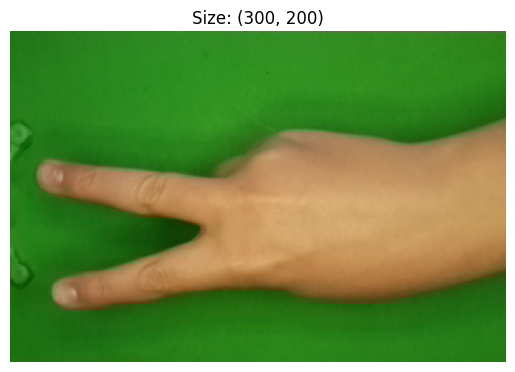

In [4]:
from PIL import Image
from matplotlib import pyplot as plt

img = Image.open(r"rps\scissors\0CSaM2vL2cWX6Cay.png")
print(f"Image size: {img.size}")  # (width, height)

# Display the image
plt.imshow(img)
plt.title(f"Size: {img.size}")
plt.axis('off')
plt.show()

In [5]:
#train YOLO
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")
model.train(data = "rps_classifier", epochs = 20, imgsz = 224, device = 0)

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Jomar\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.31M/5.31M [00:00<00:00, 11.2MB/s]


Ultralytics 8.3.162  Python-3.12.10 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=rps_classifier, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0,

100%|██████████| 5.35M/5.35M [00:00<00:00, 11.5MB/s]


AMP: checks passed 
train: Fast image access  (ping: 0.40.1 ms, read: 70.58.8 MB/s, size: 78.4 KB)


...

                   all          1          1



20 epochs completed in 0.076 hours.
Optimizer stripped from runs\classify\train\weights\last.pt, 3.0MB
Optimizer stripped from runs\classify\train\weights\best.pt, 3.0MB

Validating runs\classify\train\weights\best.pt...
Ultralytics 8.3.162  Python-3.12.10 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
train: C:\Users\Jomar\VSCode\ML\BasicML\ComputerVision\RPS\rps_classifier\train... found 1749 images in 3 classes  
val: C:\Users\Jomar\VSCode\ML\BasicML\ComputerVision\RPS\rps_classifier\val... found 439 images in 3 classes  
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 14/14 [00:00<00:00, 25.21it/s]


                   all          1          1
Speed: 0.3ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001BDF657DDC0>
curves: []
curves_results: []
fitness: 1.0
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 1.0, 'metrics/accuracy_top5': 1.0, 'fitness': 1.0}
save_dir: WindowsPath('runs/classify/train')
speed: {'preprocess': 0.33973599094600504, 'inference': 0.5644936213197701, 'loss': 0.0005173115038518754, 'postprocess': 0.0007004553456377061}
task: 'classify'
top1: 1.0
top5: 1.0

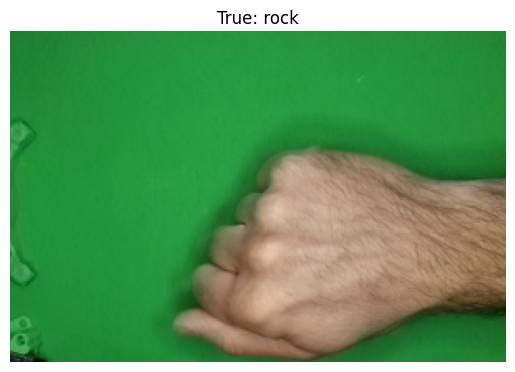


image 1/1 c:\Users\Jomar\VSCode\ML\BasicML\ComputerVision\RPS\rps_classifier\val\rock\brPQ0E5Gk9L0FHey.png: 224x224 rock 1.00, scissors 0.00, paper 0.00, 8.2ms
Speed: 11.4ms preprocess, 8.2ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
🔍 Predicted: rock (100.00% confidence)
✅ Ground Truth: rock


In [7]:
import random

val_dir = "rps_classifier/val"
val_classes = [cls for cls in os.listdir(val_dir) if os.path.isdir(os.path.join(val_dir, cls))]

random_class = random.choice(val_classes)
class_path = os.path.join(val_dir, random_class)

img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

# Display the image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"True: {random_class}")
plt.axis("off")
plt.show()

results = model.predict(source=img_path)
predicted_class = results[0].names[results[0].probs.top1]
confidence = results[0].probs.data[results[0].probs.top1].item()
print(f"Predicted: {predicted_class} ({confidence:.2%} confidence)")
print(f"Ground Truth: {random_class}")